# Build your own

The goal of this notebook is to demonstrate the modularity of OpenCDaRR, where you can build your own **things** and test it.

## Use existing dynamic and performance model
First, let's spawn our first aircraft from an existing dynamics and performance

In [1]:
from opencdarr.dynamics import FixedWing, Multirotor
from opencdarr.fleet import Agent, run_fleet
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.autopilot import CruiseAutopilot
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState

# the multirotor cruises flying north
copter = AircraftState(id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=18.0, yaw=0.0)

# since we already import the M600 and SMALL_FIXEDWING, we can just pass it here
# the CruiseAutopilot keeps the drone flying with its defined trk and gs when not in separation mode
agent_copter = Agent(copter, M600, Multirotor(), CruiseAutopilot(copter.trk, copter.gs))

## Create your own dynamic and performance model

In [2]:
# This is one of the simplest dynamic model that only follow the velocity
# This one doesn't check the performance but we pass it to the class because it is the convention
from opencdarr.dynamics.base import Dynamics, MotionCommand, odometry_update
from opencdarr.wind import NO_WIND, WindField
from opencdarr import geo
import math
from dataclasses import replace

class VelocityFollower(Dynamics):
    def step(self, state, command, perf, dt, wind=NO_WIND):
        v_east, v_north = command.v_east, command.v_north           # raises if no velocity set
        speed = math.hypot(v_east, v_north)
        trk = state.trk if speed <= perf.v_max else math.degrees(math.atan2(v_east, v_north)) % 360.0
        lat, lon = geo.forward(state.lat, state.lon, trk, speed * dt)
        return replace(state, lat=float(lat), lon=float(lon), trk=trk, gs=speed,
                       **odometry_update(state, speed, dt))

# Next is the performance model, a simple heavy cargo drone
from opencdarr.performance import Performance

CARGO = Performance(v_max=12.0, v_min=-12.0, ax=1.5,  yaw_rate_max=40.0)

# Spawn the cargo drone, now I spawn in to be directly in conflict rather than placing it somewhere else
cargo = create_conflict(copter, intr_id="CARGO", dpsi=90.0, dcpa=0.0,
                        tlos=30.0, rpz=50.0, gs_intr=10.0, side=1)

# And we create the agent, I know some of them can be streamlined, TODO next!
agent_cargo = Agent(cargo, CARGO, VelocityFollower(), CruiseAutopilot(cargo.trk, cargo.gs))

## Run the sim, no conflict resolution

In [3]:
# because the framework uses an agent based modelling, we should first collect the agent into one list

agents = [
    agent_copter, agent_cargo
]

[a.state.id for a in agents]

['COPTER', 'CARGO']

closest approach: 0.6 m   loss of separation: True
run ended at t = 44.9 s


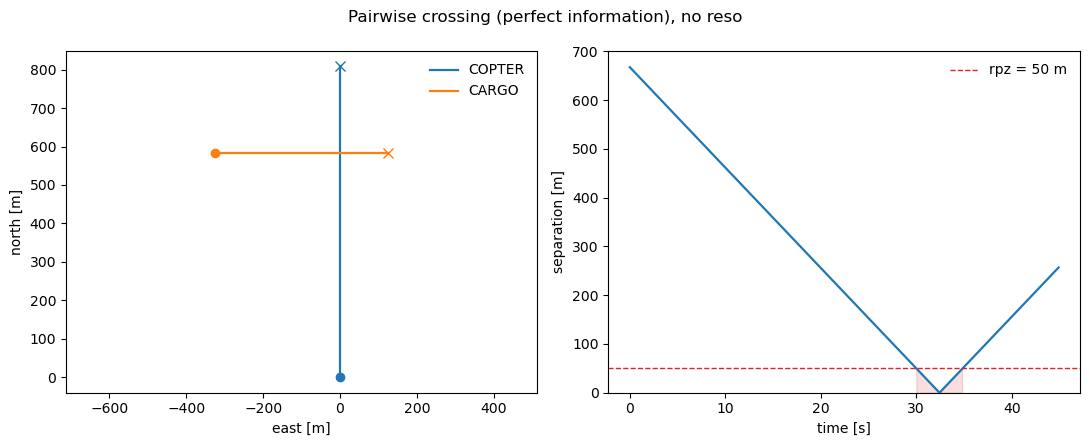

In [4]:
from opencdarr.cd import StateBased
from opencdarr.viz import plot_pairwise

run = run_fleet(
    agents, rpz=50.0, t_lookahead=20.0, dt=0.1,
    detector= StateBased(), resolver=None,
    recovery= None,
    done_timeout=10.0,
    record=True,
)
print(f"closest approach: {run.min_sep:.1f} m   loss of separation: {run.los}")
print(f"run ended at t = {run.frames[-1].t:.1f} s")

fig = plot_pairwise(run, rpz=50.0, title="Pairwise crossing (perfect information), no reso")
# fig.savefig("pairwise_clean.png", dpi=150)   # the figure handle is yours to keep

## Run the sim, with conflict resolution

closest approach: 97.7 m   loss of separation: False
run ended at t = 42.1 s


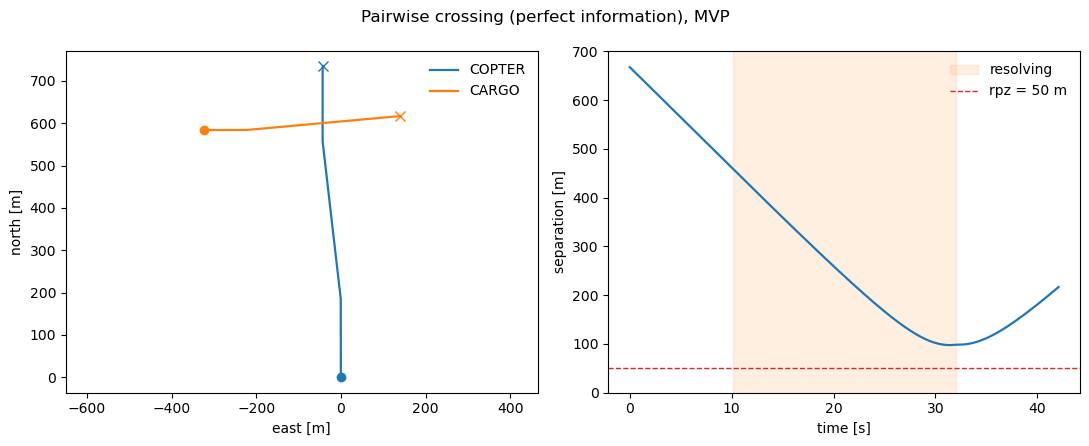

In [5]:
from opencdarr.cd import StateBased
from opencdarr.cr import MVP, VO
from opencdarr.crr import PastCPA

# we are running this sim with MVP, but you can also try with VO
run = run_fleet(
    agents, rpz=50.0, t_lookahead=20.0, dt=0.1,
    detector= StateBased(), resolver=MVP(),
    recovery= PastCPA(bouncing_guard=True),
    done_timeout=10.0,
    record=True,
)
print(f"closest approach: {run.min_sep:.1f} m   loss of separation: {run.los}")
print(f"run ended at t = {run.frames[-1].t:.1f} s")

fig = plot_pairwise(run, rpz=50.0, title="Pairwise crossing (perfect information), MVP")
# fig.savefig("pairwise_clean.png", dpi=150)   # the figure handle is yours to keep

## Run the sim, with your own conflict resolution

In [6]:
from opencdarr.cr.base import ConflictResolver
from opencdarr.kinematics import velocity_enu, relative_enu
from collections.abc import Sequence

# Let's say this is your conflict resolution algorithm, a simplified version
class CloseRangeAvoid(ConflictResolver):
    """Hold course until an intruder is within `trigger` m, then turn 90 deg right."""

    def __init__(self, trigger: float = 70.0) -> None:
        self.trigger = trigger

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)   # own's current ground velocity
        nearest = min((relative_enu(own, i).dist for i in intruders), default=float('inf'))
        if nearest <= self.trigger:
            return MotionCommand(target_velocity=(v_north, -v_east))  # 90 deg right, same speed
        return MotionCommand(target_velocity=(v_east, v_north))       # else: unchanged

closest approach: 49.9 m   loss of separation: True
run ended at t = 60.1 s


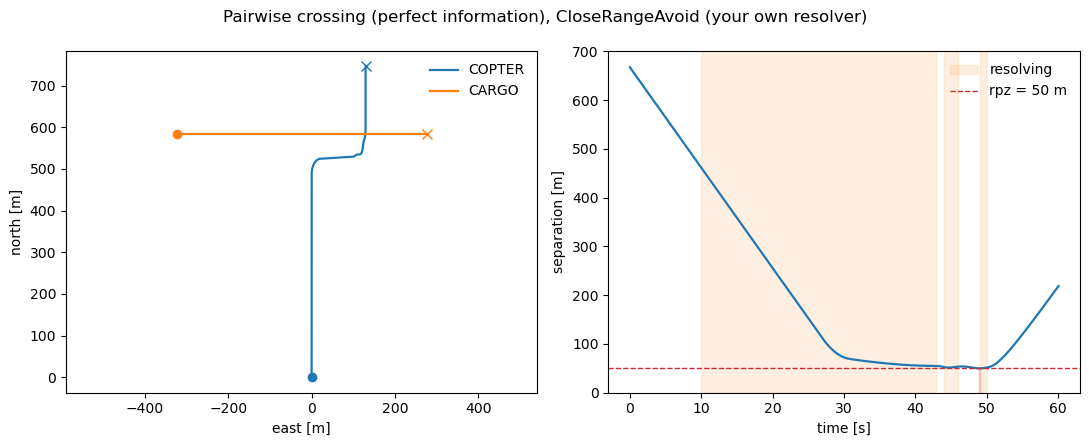

In [7]:
# Now we can run the sim with your conflict resolution!

from opencdarr.cd import StateBased
from opencdarr.cr import MVP, VO
from opencdarr.crr import PastCPA

# we are running this sim with MVP, but you can also try with VO
run = run_fleet(
    agents, rpz=50.0, t_lookahead=20.0, dt=0.1,
    detector= StateBased(), resolver=CloseRangeAvoid(120),
    recovery= PastCPA(bouncing_guard=True),
    done_timeout=10.0,
    record=True,
)
print(f"closest approach: {run.min_sep:.1f} m   loss of separation: {run.los}")
print(f"run ended at t = {run.frames[-1].t:.1f} s")

fig = plot_pairwise(run, rpz=50.0, title="Pairwise crossing (perfect information), CloseRangeAvoid (your own resolver)")
# fig.savefig("pairwise_clean.png", dpi=150)   # the figure handle is yours to keep

## Run the sim, with CNS uncertainty

We have seen before that MVP performs better, but we want to stress test it by introducing navigation uncertainty

closest approach: 102.5 m   loss of separation: False


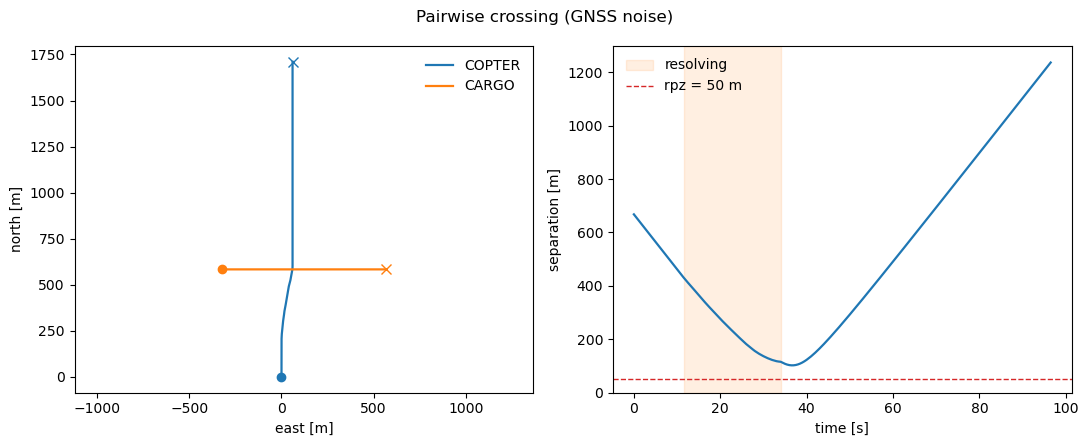

In [8]:
from dataclasses import replace
from opencdarr.cns.navigation import GnssNavigation
from opencdarr import rng

# here we asign the uncertainty into each agents
# all of them has 15 m and 1.5 m/s position and velocity uncertainty respectively
noisy_agents = [replace(a, state=replace(a.state, pos_ci95=15.0, vel_ci95=1.5)) for a in agents]

noisy_run = run_fleet(
    noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(),
    recovery=PastCPA(bouncing_guard=True),
    navigation=GnssNavigation(), rng=rng.generator(rng.root_seed_sequence(42)),
    stop_within=100.0, done_timeout=60.0,   # stop once both reach their waypoint
    record=True,
)
print(f"closest approach: {noisy_run.min_sep:.1f} m   loss of separation: {noisy_run.los}")

fig = plot_pairwise(noisy_run, rpz=50.0, title="Pairwise crossing (GNSS noise)")

Still okay-ish, what if I add communication uncertainty?

closest approach: 84.6 m   loss of separation: False


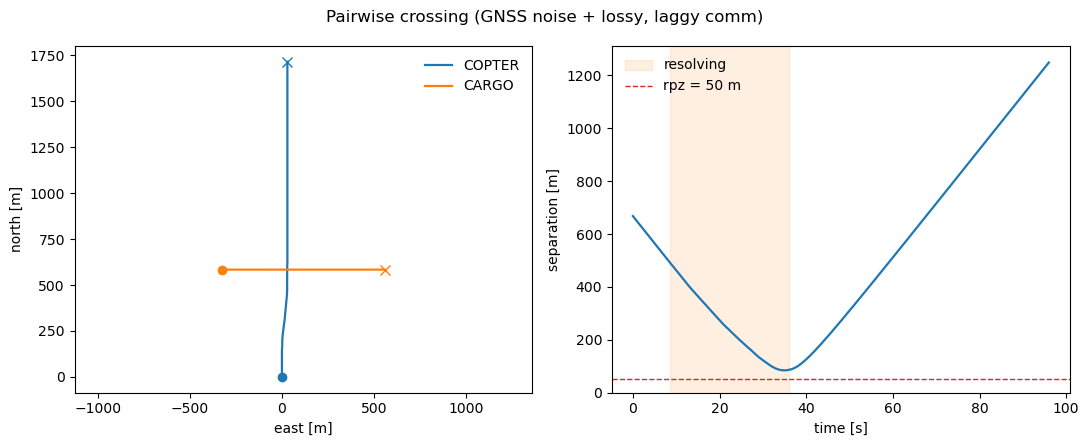

In [9]:
from opencdarr.cns import Comm, lognormal_latency

# one root seed -> two independent, reproducible streams: navigation and communication
nav_seq, comm_seq = rng.spawn(rng.root_seed_sequence(42), 2)

comm = Comm(
    reception_prob={                       # DIRECTED: keyed (source, receiver) = "from -> to"
        ("COPTER", "CARGO"): 0.9,          #   COPTER's broadcasts reach CARGO 90% of the time
        ("CARGO", "COPTER"): 0.6,          #   CARGO's reach COPTER only 60% — asymmetric link
    },                                     #   any pair you omit defaults to 1.0 (perfect)
    latency=lognormal_latency(median=0.5, sigma=0.4),   # seconds; delivered at t_meas + delay
)

noisy_run = run_fleet(
    noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(margin=1.1),
    recovery=PastCPA(bouncing_guard=True),
    navigation=GnssNavigation(), rng=rng.generator(nav_seq),
    communication=comm,          comm_rng=rng.generator(comm_seq),   # comm needs its own stream
    stop_within=100.0, done_timeout=60.0,   # stop once both reach their waypoint
    record=True,
)
print(f"closest approach: {noisy_run.min_sep:.1f} m   loss of separation: {noisy_run.los}")

fig = plot_pairwise(noisy_run, rpz=50.0, title="Pairwise crossing (GNSS noise + lossy, laggy comm)")

## Run a MC Simulation
Whoaa, that was actually pretty good. But the CPA distance is smaller now. Maybe we need to run more simulation! Using previously defined comm and nav...

In [10]:
n_runs = 200
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.2,
        detector=StateBased(), resolver=MVP(),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(nav_seq),
        communication=comm,          comm_rng=rng.generator(comm_seq),   # per-run comm stream now
        stop_within=100.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for nav_seq, comm_seq in (rng.spawn(sub, 2) for sub in rng.spawn(rng.root_seed_sequence(42), n_runs))
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 0/200 runs  (rate ~ 0.000)
closest approach over the sweep: min 56.5 m, median 96.7 m


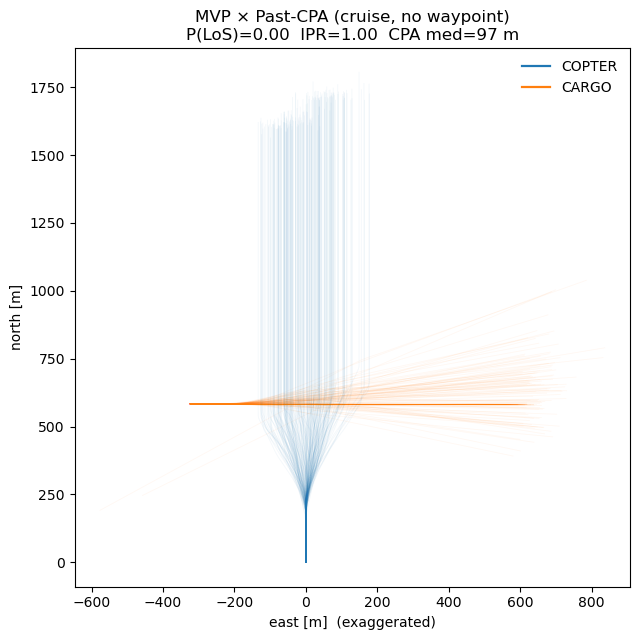

In [11]:
from opencdarr.viz import plot_pairwise_montecarlo


## if you encounter error here, most likely you haven't uncomment record=True above
fig = plot_pairwise_montecarlo(outcomes, title="MVP × Past-CPA (cruise, no waypoint)")

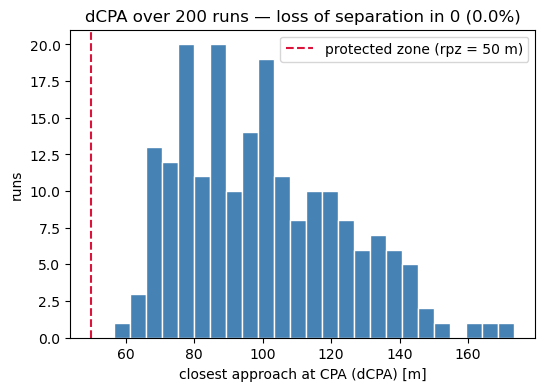

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(min_seps, bins=25, color="steelblue", edgecolor="white")
ax.axvline(50.0, color="crimson", linestyle="--", label="protected zone (rpz = 50 m)")
ax.set_xlabel("closest approach at CPA (dCPA) [m]")
ax.set_ylabel("runs")
ax.set_title(f"dCPA over {len(min_seps)} runs — loss of separation in {lost} ({lost/len(min_seps):.1%})")
ax.legend()
plt.show()

## Run a MC Simulation, but with waypoint

In [13]:
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.mission import Mission

# from the previous mission assignment of an agent, we can write the copter agent a waypoint for its mission
wp_copter = geo.forward(copter.lat, copter.lon, copter.trk, copter.gs * 75.0)
agent_copter = Agent(copter, M600,  Multirotor(),     WaypointAutopilot(Mission(goto=wp_copter)))

# update the agent now
agents = [
    agent_copter, agent_cargo
]
noisy_agents = [replace(a, state=replace(a.state, pos_ci95=15.0, vel_ci95=1.5)) for a in agents]

# and let it go... let it go...
n_runs = 200
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.2,
        detector=StateBased(), resolver=MVP(),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(nav_seq),
        communication=comm,          comm_rng=rng.generator(comm_seq),   # per-run comm stream now
        stop_within=50.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for nav_seq, comm_seq in (rng.spawn(sub, 2) for sub in rng.spawn(rng.root_seed_sequence(42), n_runs))
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 0/200 runs  (rate ~ 0.000)
closest approach over the sweep: min 56.5 m, median 95.9 m


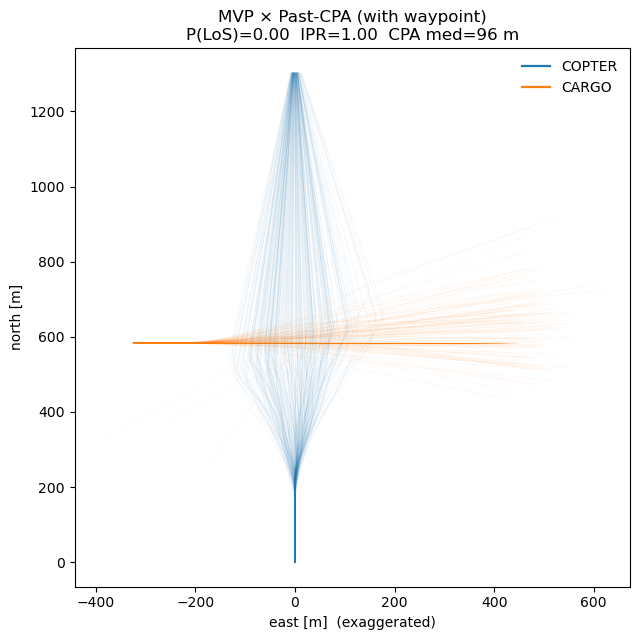

In [14]:
from opencdarr.viz import plot_pairwise_montecarlo


## if you encounter error here, most likely you haven't uncomment record=True above
fig = plot_pairwise_montecarlo(outcomes, title="MVP × Past-CPA (with waypoint)")

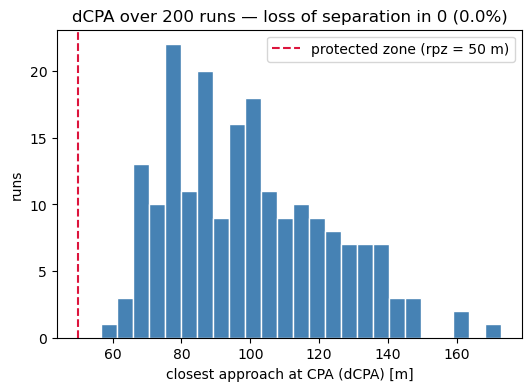

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(min_seps, bins=25, color="steelblue", edgecolor="white")
ax.axvline(50.0, color="crimson", linestyle="--", label="protected zone (rpz = 50 m)")
ax.set_xlabel("closest approach at CPA (dCPA) [m]")
ax.set_ylabel("runs")
ax.set_title(f"dCPA over {len(min_seps)} runs — loss of separation in {lost} ({lost/len(min_seps):.1%})")
ax.legend()
plt.show()

## Finally, with wind

In [16]:
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.mission import Mission

# from the previous mission assignment of an agent, we can write the copter agent a waypoint for its mission
wp_copter = geo.forward(copter.lat, copter.lon, copter.trk, copter.gs * 75.0)
agent_copter = Agent(copter, M600,  Multirotor(),     WaypointAutopilot(Mission(goto=wp_copter)))

# update the agent now
agents = [
    agent_copter, agent_cargo
]
noisy_agents = [replace(a, state=replace(a.state, pos_ci95=15.0, vel_ci95=1.5)) for a in agents]

wind = WindField.from_met(coming_from_deg=270.0, speed=10.0)

# and let it go... let it go...
n_runs = 200
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.2,
        wind = wind,
        detector=StateBased(), resolver=MVP(),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(nav_seq),
        communication=comm,          comm_rng=rng.generator(comm_seq),   # per-run comm stream now
        stop_within=100.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for nav_seq, comm_seq in (rng.spawn(sub, 2) for sub in rng.spawn(rng.root_seed_sequence(42), n_runs))
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 2/200 runs  (rate ~ 0.010)
closest approach over the sweep: min 34.8 m, median 96.7 m


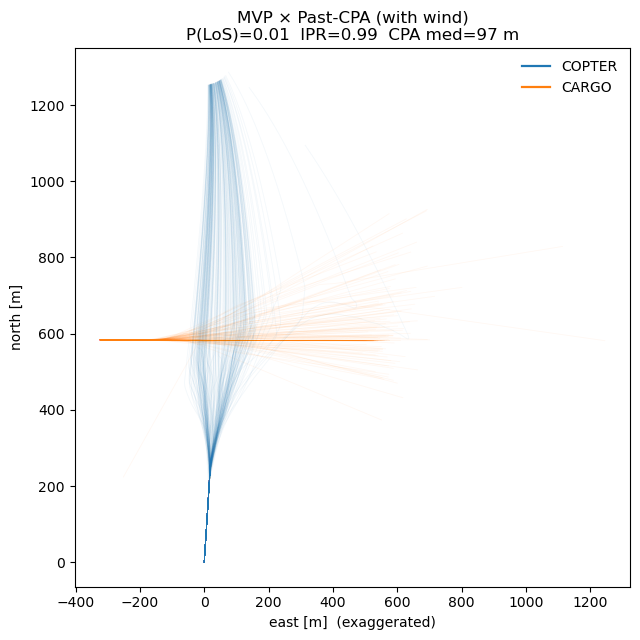

In [17]:
from opencdarr.viz import plot_pairwise_montecarlo


## if you encounter error here, most likely you haven't uncomment record=True above
fig = plot_pairwise_montecarlo(outcomes, title="MVP × Past-CPA (with wind)")

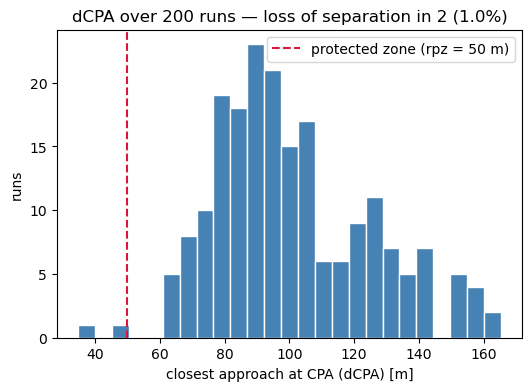

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(min_seps, bins=25, color="steelblue", edgecolor="white")
ax.axvline(50.0, color="crimson", linestyle="--", label="protected zone (rpz = 50 m)")
ax.set_xlabel("closest approach at CPA (dCPA) [m]")
ax.set_ylabel("runs")
ax.set_title(f"dCPA over {len(min_seps)} runs — loss of separation in {lost} ({lost/len(min_seps):.1%})")
ax.legend()
plt.show()